In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")

In [8]:
df = pd.read_csv(r"C:\Users\diaca\Downloads\superstore_dataset2012.csv")
df.head()


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,21896,ID-2012-71858,1/2/2012,7/2/2012,Standard Class,CP-12085,Cathy Prescott,Corporate,Jakarta,Jakarta,...,TEC-PH-10003784,Technology,Phones,"Motorola Signal Booster, with Caller ID",593.9895,5,0.17,-71.7105,52.22,Medium
1,4323,MX-2012-154459,1/2/2012,6/2/2012,Standard Class,JF-15190,Jamie Frazer,Consumer,Santiago,Santiago,...,TEC-PH-10002102,Technology,Phones,"Nokia Headset, Cordless",151.9200,3,0.00,71.4000,32.94,High
2,2829,MX-2012-114461,1/2/2012,5/2/2012,Standard Class,RM-19375,Raymond Messe,Consumer,Escuintla,Escuintla,...,TEC-AC-10002760,Technology,Accessories,"Memorex Memory Card, Erganomic",200.1600,3,0.00,0.0000,28.95,High
3,2828,MX-2012-114461,1/2/2012,5/2/2012,Standard Class,RM-19375,Raymond Messe,Consumer,Escuintla,Escuintla,...,FUR-CH-10001423,Furniture,Chairs,"Harbour Creations Rocking Chair, Black",192.8800,2,0.00,54.0000,19.27,High
4,6762,MX-2012-151904,1/2/2012,3/2/2012,First Class,DJ-13420,Denny Joy,Corporate,Villa Canales,Guatemala,...,OFF-PA-10003571,Office Supplies,Paper,"Enermax Cards & Envelopes, Recycled",94.0200,3,0.00,1.8600,10.73,Medium


In [9]:
df.info()
df.isnull().sum()
df.describe()

print("Resumen del dataset:")
print(df.info())
print("\nValores nulos por columna:")
print(df.isnull().sum())
print("\nEstadísticas descriptivas:")
print(df.describe())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4246 entries, 0 to 4245
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          4246 non-null   int64  
 1   Order ID        4246 non-null   object 
 2   Order Date      4246 non-null   object 
 3   Ship Date       4246 non-null   object 
 4   Ship Mode       4246 non-null   object 
 5   Customer ID     4246 non-null   object 
 6   Customer Name   4246 non-null   object 
 7   Segment         4246 non-null   object 
 8   City            4246 non-null   object 
 9   State           4246 non-null   object 
 10  Country         4246 non-null   object 
 11  Postal Code     823 non-null    float64
 12  Market          4246 non-null   object 
 13  Region          4246 non-null   object 
 14  Product ID      4246 non-null   object 
 15  Category        4246 non-null   object 
 16  Sub-Category    4246 non-null   object 
 17  Product Name    4246 non-null   o

In [10]:
df["Order Date"] = pd.to_datetime(df["Order Date"], errors="coerce")
df = df.dropna(subset=["Sales", "Profit"])
print("Datos preparados correctamente")


Datos preparados correctamente


In [11]:
corr = df[["Sales", "Profit", "Quantity"]].corr()
corr


,Sales,Profit,Quantity
Sales,1.000000,0.477267,0.343441
Profit,0.477267,1.000000,0.118365
Quantity,0.343441,0.118365,1.000000


In [13]:
import os
os.makedirs("figuras", exist_ok=True)
print("✅ Carpeta 'figuras' creada correctamente.")

✅ Carpeta 'figuras' creada correctamente.


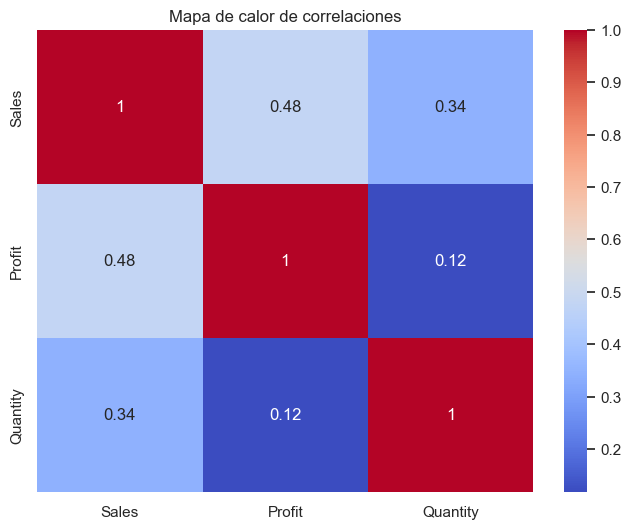

In [14]:
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Mapa de calor de correlaciones")

plt.savefig("figuras/heatmap_correlaciones_superstore.png", dpi=300, bbox_inches="tight")

plt.show()


In [15]:
import os
print(os.path.exists("figuras/heatmap_correlaciones_superstore.png"))


True


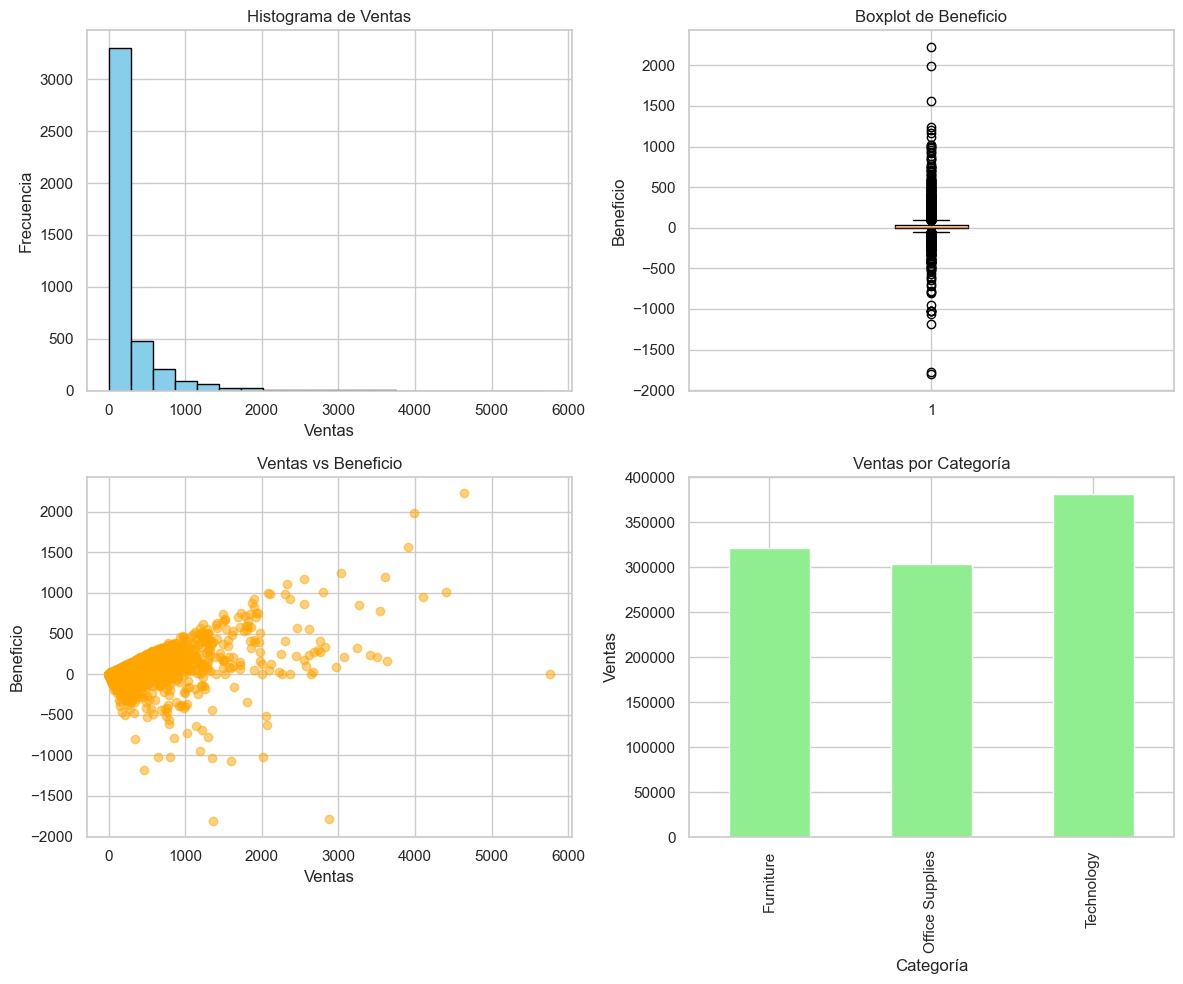

In [17]:
fig, axs = plt.subplots(2, 2, figsize=(12, 10))

# Histograma de Ventas
axs[0, 0].hist(df["Sales"], bins=20, color="skyblue", edgecolor="black")
axs[0, 0].set_title("Histograma de Ventas")
axs[0, 0].set_xlabel("Ventas")
axs[0, 0].set_ylabel("Frecuencia")

# Boxplot de Beneficio
axs[0, 1].boxplot(df["Profit"])
axs[0, 1].set_title("Boxplot de Beneficio")
axs[0, 1].set_ylabel("Beneficio")

# Dispersión Ventas vs Beneficio
axs[1, 0].scatter(df["Sales"], df["Profit"], alpha=0.5, color="orange")
axs[1, 0].set_title("Ventas vs Beneficio")
axs[1, 0].set_xlabel("Ventas")
axs[1, 0].set_ylabel("Beneficio")

# Barras por Categoría
df.groupby("Category")["Sales"].sum().plot(kind="bar", ax=axs[1, 1], color="lightgreen")
axs[1, 1].set_title("Ventas por Categoría")
axs[1, 1].set_xlabel("Categoría")
axs[1, 1].set_ylabel("Ventas")

plt.tight_layout()
plt.show()
